In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
paragraphs = pd.read_parquet('model/paragraphs.parquet')

## Preprocess

In [3]:
wordcounts = paragraphs.content.str.split(' ').str.len()

In [4]:
wordcounts.max()

1087

(array([2.3262e+04, 3.5120e+03, 1.1130e+03, 1.2700e+02, 9.0000e+00,
        2.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]),
 array([1.000e+00, 1.096e+02, 2.182e+02, 3.268e+02, 4.354e+02, 5.440e+02,
        6.526e+02, 7.612e+02, 8.698e+02, 9.784e+02, 1.087e+03]),
 <BarContainer object of 10 artists>)

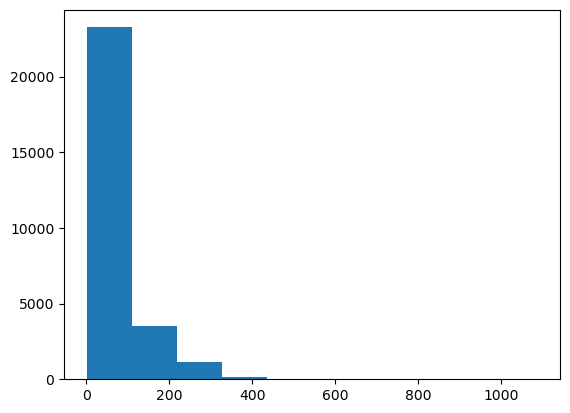

In [5]:
plt.hist(wordcounts)

In [6]:
wordcounts.describe()

count    28026.000000
mean        64.498216
std         66.683235
min          1.000000
25%         15.000000
50%         48.000000
75%         88.000000
max       1087.000000
Name: content, dtype: float64

In [7]:
import nltk
nltk.download("punkt")
from nltk.tokenize import sent_tokenize, word_tokenize

def split_into_word_chunks(text, max_words=700):
    sentences = sent_tokenize(text)

    chunks = []
    current_chunk = []
    current_words = 0

    for sentence in sentences:
        word_count = len(word_tokenize(sentence))

        # if adding this sentence would exceed the limit, flush
        if current_words + word_count > max_words:
            if current_chunk:  # avoid empty chunks
                chunks.append(" ".join(current_chunk))
            current_chunk = [sentence]
            current_words = word_count
        else:
            current_chunk.append(sentence)
            current_words += word_count

    # add last chunk
    if current_chunk:
        chunks.append(" ".join(current_chunk))

    return chunks



[nltk_data] Downloading package punkt to /home/ai-tonchev/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [8]:
def limit_text(df, limit = 600, text_col = 'content', id_col = 'paragraphID'):
    
    chunk_records = []
    
    for i in df.index:
        p_id = df.at[i, id_col]
        p_cont = df.at[i, text_col]
        
        if len(p_cont)>limit:
            chunks = split_into_word_chunks(p_cont)
            ch_i = 0
            for ch in chunks:
                chunk_records.append({
                    'paragraphID': p_id,
                    'chunkID': f"{p_id}_{ch_i}",
                    'order': ch_i,
                    'content': ch
                })
                
                ch_i += 1
                
        else:
            chunk_records.append({
                    'paragraphID': p_id,
                    'chunkID': f"{p_id}_0",
                    'order': 0,
                    'content': p_cont
                })
            
    return pd.DataFrame(chunk_records)

In [9]:
limited = limit_text(paragraphs, limit=200, text_col='content', id_col='paragraphID')

In [10]:
l300 = limit_text(paragraphs, limit=300, text_col='content', id_col='paragraphID')

# Embeddings

In [11]:
from sentence_transformers import SentenceTransformer

def get_embeddings_for_model(df, model_name, text_col='content'):
    """
    Get embeddings for a DataFrame using a specified model.
    
    Parameters:
    - df: DataFrame containing the text data.
    - model: The model to use for generating embeddings.
    - text_col: Column name containing the text data.
    - id_col: Column name for unique identifiers.
    
    Returns:
    - DataFrame with embeddings and identifiers.
    """
    model = SentenceTransformer(model_name)
    
    embeddings = model.encode(df[text_col].tolist(), show_progress_bar=True)
    
    np.save(f'embeddings/paragraphs_{model_name}.npy', embeddings)

In [12]:
get_embeddings_for_model(l300, 'all-mpnet-base-v2')

Batches:   0%|          | 0/876 [00:00<?, ?it/s]

In [40]:
limited.to_parquet('model/paragraphs_limited.parquet', index=False)